In [10]:
import yfinance as yf
import numpy as np 
import matplotlib.pyplot as plt

In [11]:
portfolio = {
    "NIFTY": "^NSEI",
    "TCS": "TCS.NS",
    "RELIANCE": "RELIANCE.NS"
}


In [12]:
prices = yf.download(
    list(portfolio.values()),
         start="2024-01-01",
         end="2025-01-01"
)["Close"]

[*********************100%***********************]  3 of 3 completed


In [13]:
returns = prices.pct_change().dropna()

In [14]:
# Assuming portfolio weights
# Nifty50= 50%, TCS= 20%, Reliance=30%
weights = np.array([0.5, 0.2, 0.3])

In [15]:
portfolio_returns = returns.dot(weights)

In [20]:
# Historical Value at Risk Function
def historical_var(returns, confidence_level):
    percentile = (1 - confidence_level) * 100
    var = np.percentile(returns, percentile)

    return abs(var)

In [21]:
# Calculating confidence level if Var is 95% and 99%
var_95 = historical_var(portfolio_returns, 0.95)

var_99 = historical_var(portfolio_returns, 0.99)

print(f"95% Historical VaR = {var_95:.2%}")
print(f"99% Historical VaR = {var_99:.2%}")

95% Historical VaR = 1.66%
99% Historical VaR = 2.65%


In [26]:
# Assuming value of Rs 1,00,00,000
portfolio_value = 10_000_000

var_95_rupees = portfolio_value * var_95
var_99_rupees = portfolio_value * var_99

print(f"95% VaR = RS {var_95_rupees:,.0f}")
print(f"99% VaR = Rs {var_99_rupees:,.0f}")

95% VaR = RS 165,630
99% VaR = Rs 265,482


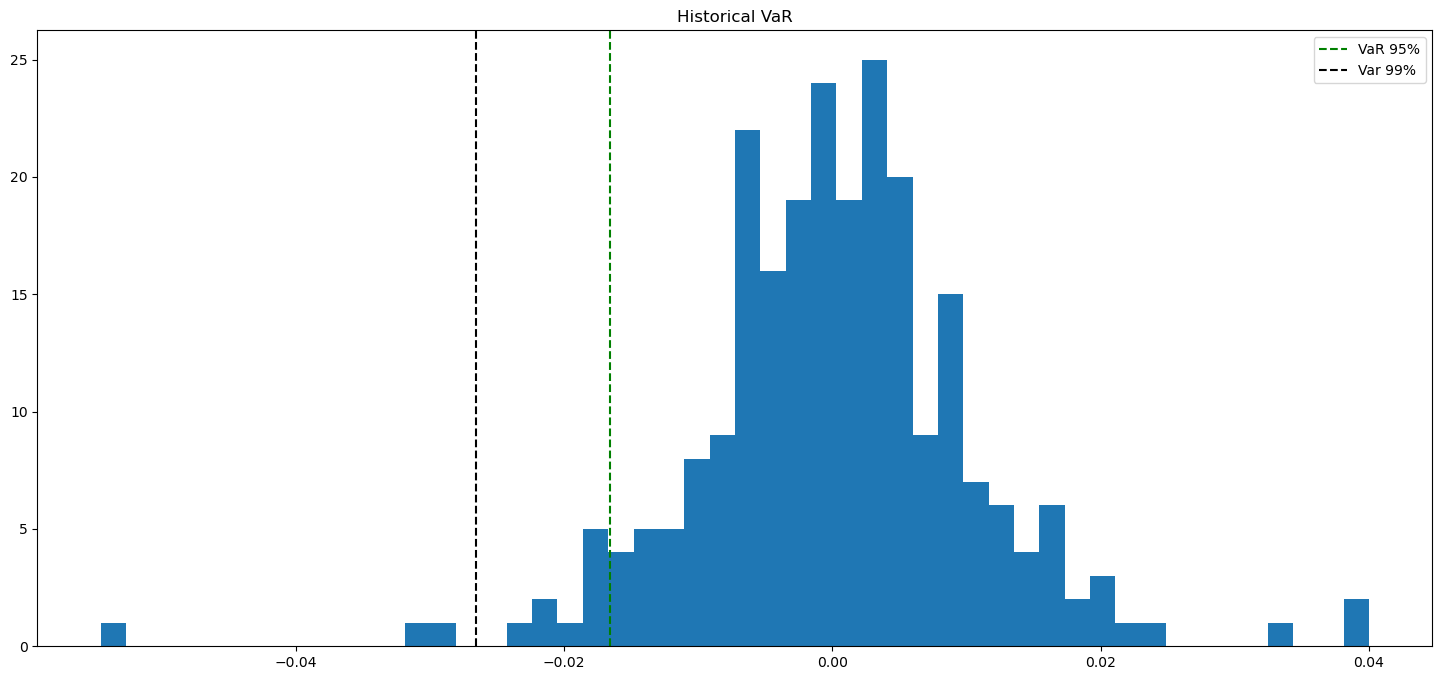

In [31]:
# Visualization
plt.figure(figsize=(18,8))
plt.hist(portfolio_returns, bins=50)
plt.axvline(-var_95, linestyle="--", label="VaR 95%", color="Green")
plt.axvline(-var_99, linestyle="--", label="Var 99%", color="Black")
plt.title("Historical VaR")
plt.legend()
plt.show()